# Definiendo el mejor modelo
Ahora que ya tengo las variables, procedo a probar y a definir cuál es el mejor modelo predicción usando metodología FIGS.
La metodología FIGS (Focused Identification of Germplasm Strategy) parte de un principio clave:

*Los ambientes donde fueron colectadas las accesiones explican, en parte, su adaptación a condiciones extremas (como sequía o exceso de agua).*

Para los modelos a usar, he definidio crear una variable objetivo llamada "resistente a sequía". Esta variable será de valor binario (1/0) y se genera a partir de los datos del ambiente histórico donde se colectó la accesión.
* **Resistente a sequía** = Accesiones colectadas en ambientes áridos o con baja precipitación y alta evapotranspiración.
* **No resistente** = Ambientes húmedos, con alta humedad o baja aridez.


# Esta parte por editar
En este caso las variables que usaré para crear la variable objetivo son:
* Precipitación anual (bio12)
* Precipitación del trimestre más seco (bio17)
* Temperatura máxima del mes más cálido (bio5)
* Índice de aridez (current_30arcsec_aridityIndexThornthwaite)
* Índice de humedad climática (current_30arcsec_climaticMoistureIndex)
* Evapotranspiración potencial (current_30arcsec_annualPET)

# ************************************************************************************************************************************************************

## Importando Librerías ##
# ************************************************************************************************************************************************************

In [14]:
import h2o
from h2o.automl import H2OAutoML
import pandas as pd
import numpy as np

In [15]:
h2o.cluster().shutdown()

H2O session _sid_869f closed.


In [15]:


# Inicializar el clúster local de H2O
h2o.init(max_mem_size="16G")


Checking whether there is an H2O instance running at http://localhost:54321. connected.
Please download and install the latest version from: https://h2o-release.s3.amazonaws.com/h2o/latest_stable.html


H2O_cluster_uptime:,1 hour 6 mins
H2O_cluster_timezone:,America/Bogota
H2O_data_parsing_timezone:,UTC
H2O_cluster_version:,3.46.0.7
H2O_cluster_version_age:,7 months and 22 days
H2O_cluster_name:,H2O_from_python_guill_qs4dzc
H2O_cluster_total_nodes:,1
H2O_cluster_free_memory:,16.00 Gb
H2O_cluster_total_cores:,16
H2O_cluster_allowed_cores:,16
H2O_cluster_status:,"locked, healthy"


## Paso 1 Carga del dataset ##
# ************************************************************************************************************************************************************

In [2]:
# ==========================================
# CARGA Y REVISIÓN DEL DATASET
# ==========================================

# Cargar el archivo
df = pd.read_csv("./dataset_entrada/dataset_reducido_no_colineal.csv")
df_full = df.copy()
# Mostrar información general
print("Dimensiones:", df.shape)
print("\nPrimeras filas:")
display(df.head())

print("\nResumen de tipos de datos y nulos:")
display(df.info())


Dimensiones: (3357, 67)

Primeras filas:


,DOI,ACCENUMB,CURATION,GENUS,SPECIES,GRIN_NAME,ORIGCTY,COLLSITE,DECLATITUDE,DECLONGITUDE,...,prec_6,prec_7,srad_1,srad_10,srad_3,srad_4,srad_5,srad_9,wind_1,wind_10
0,10.18730/JKECH,G16570,FULL,Phaseolus,vulgaris,Phaseolus vulgaris,IRN,KARAJ - MARKAZI,35.81,50.93,...,-1.062011,-1.045993,-1.131852,-0.559309,-0.926190,-0.166400,0.805037,1.113787,-0.158827,0.322904
1,10.18730/JKEKR,G16576,FULL,Phaseolus,vulgaris,Phaseolus vulgaris,IRN,KERMANSHAH CHAMCHAL - KERMANSHAH - KERMANSHAHAN,34.32,47.07,...,-1.109707,-1.073673,-1.154124,-0.067053,-0.746152,-0.220326,0.879623,2.107256,-0.372930,0.322904
2,10.18730/JZXX0,G990,FULL,Phaseolus,vulgaris,Phaseolus vulgaris,IRN,AHWAZ - KHUZESTAN,31.32,48.70,...,-1.128786,-1.082899,-0.781826,0.306394,-0.175266,0.335804,1.118016,2.205778,0.162328,0.064891
3,10.18730/JZXWU,G989,FULL,Phaseolus,vulgaris,Phaseolus vulgaris,IRN,KAZERUN - FARS,29.62,51.63,...,-1.128786,-1.082899,-0.363673,0.921358,0.203504,0.689795,1.501642,2.629266,-0.158827,-0.064115
4,10.18730/JZXT$,G987,FULL,Phaseolus,vulgaris,Phaseolus vulgaris,IRN,SHIRAZ - FARS,29.60,52.53,...,-1.119246,-1.073673,-0.417170,1.029527,0.073796,0.454904,1.196261,2.629266,-0.051775,-0.064115



Resumen de tipos de datos y nulos:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3357 entries, 0 to 3356
Data columns (total 67 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   DOI                                        3357 non-null   object 
 1   ACCENUMB                                   3357 non-null   object 
 2   CURATION                                   3357 non-null   object 
 3   GENUS                                      3357 non-null   object 
 4   SPECIES                                    3357 non-null   object 
 5   GRIN_NAME                                  3357 non-null   object 
 6   ORIGCTY                                    3357 non-null   object 
 7   COLLSITE                                   3357 non-null   object 
 8   DECLATITUDE                                3357 non-null   float64
 9   DECLONGITUDE                               3357 non-null   f

None

In [3]:
# ============================================================
# Crear variable objetivo (simplificada para prueba inicial)
# ============================================================

# Lógica: valores bajos de aridez (menos estrés), PET y CMI intermedios
df["Resistencia_Sequia"] = np.where(
    (df["current_30arcsec_aridityIndexThornthwaite"] < df["current_30arcsec_aridityIndexThornthwaite"].median()) &
    (df["current_30arcsec_annualPET"] < df["current_30arcsec_annualPET"].median()) &
    (df["current_30arcsec_climaticMoistureIndex"] > df["current_30arcsec_climaticMoistureIndex"].median()),
    1, 0
)

# Verificar balance de clases
print(df["Resistencia_Sequia"].value_counts(normalize=True))


Resistencia_Sequia
0    0.704498
1    0.295502
Name: proportion, dtype: float64


## Eliminando Columnas ## 
Elimino las columnas que use para crear la variable objetivo. Esto lo hago porque al entrenar los modelos ya saben la respuesta antes de entrenar, porque la variable objetivo fue calculada directamente con esas columnas.
# ************************************************************************************************************************************************************

In [4]:


df = df.drop(columns=[
    "current_30arcsec_aridityIndexThornthwaite",
    "current_30arcsec_annualPET",
    "current_30arcsec_climaticMoistureIndex",
    "DECLATITUDE", "DECLONGITUDE",
    "DOI", "ACCENUMB", "CURATION", "GRIN_NAME", "ORIGCTY"])

In [20]:
# Convertir a H2OFrame
hf = h2o.H2OFrame(df)

# Definir variables predictoras y objetivo
y = "Resistencia_Sequia"
x = [col for col in hf.columns if col not in [y]]

# Verificar dimensiones
hf.describe()


Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%


Rows:3357
Cols:68

,DOI,ACCENUMB,CURATION,GENUS,SPECIES,GRIN_NAME,ORIGCTY,COLLSITE,DECLATITUDE,DECLONGITUDE,SAMPSTAT,ELEVATION,COLLSRC,MODCF_CloudForestPrediction,MODCF_meanannual,MODCF_seasonality_concentration,current_30arcsec_annualPET,current_30arcsec_aridityIndexThornthwaite,current_30arcsec_climaticMoistureIndex,current_30arcsec_continentality,AWCh1_M_sl1,AWCh1_M_sl2,AWCtS_M_sl1,CECSOL_M_sl1,CECSOL_M_sl2,CLYPPT_M_sl1,CRFVOL_M_sl1,BDRICM_M,ORCDRC_M_sl1,ORCDRC_M_sl2,OCDENS_M_sl1,OCSTHA_M_sd1,PHIHOX_M_sl1,PHIKCL_M_sl1,BDRLOG_M,SNDPPT_M_sl1,SLTPPT_M_sl1,SLGWRB,WWP_M_sl1,ACDWRB_M_ss,bio1,bio10,bio12,bio13,bio14,bio15,bio18,bio19,bio2,bio3,bio8,bio9,prec_1,prec_10,prec_11,prec_4,prec_5,prec_6,prec_7,srad_1,srad_10,srad_3,srad_4,srad_5,srad_9,wind_1,wind_10,Resistencia_Sequia
type,string,string,enum,enum,enum,enum,enum,string,real,real,real,real,real,real,real,real,real,real,real,real,real,real,real,real,real,real,real,real,real,real,real,real,real,real,real,real,real,real,real,real,real,real,real,real,real,real,real,real,real,real,real,real,real,real,real,real,real,real,real,real,real,real,real,real,real,real,real,int
mins,NaN,NaN,,,,,,NaN,-38.03,-123.25,-2.9470184280009937,-1.7313909480576033,-2.902539935203636,-0.6180967779415024,-2.67806184905012,-1.5377304677436885,-2.860822481887594,-2.789779480765997,-2.343062603258796,-1.013669472717795,-4.549472427604171,-5.82647884809277,-2.8030046663244432,-2.3445427990812053,-2.626026170769608,-3.5844189665303188,-1.4958970187309133,-4.838701570648681,-1.4874469887424702,-1.3472192862608754,-1.9701529294531743,-2.111182666237144,-2.273661691754548,-3.457293271262553,-1.353287997233943,-3.424942477539436,-3.146616838708615,-0.1099513511812154,-4.055672494013865,-1.1698836982734446,-3.7146582266803474,-4.131771819329132,-1.8210489181806069,-1.8480900176832689,-0.8120047329490826,-2.0539501084581486,-1.6251302951078737,-0.8754433635726453,-2.4435380181441726,-2.218648539160718,-4.269567131925109,-5.596865965711562,-0.9902473241872196,-1.2139897223537115,-1.1002297895954634,-1.1071331609448072,-1.1939927653545588,-1.1287855512562417,-1.0828993213351026,-2.563834629222031,-3.48588665563591,-2.690042873671915,-2.5755243544497777,-3.5341791761848587,-3.6740562744026937,-1.8716521379977928,-1.870203465268774,0.0
mean,NaN,NaN,,,,,,NaN,14.711462615430445,-46.307566279416,-2.0274580625478933e-17,6.700369425960417e-17,-4.743384504624082e-17,-3.6404798446632025e-16,3.231464575093046e-16,-1.6360610782806262e-16,-6.239583502654078e-16,-7.49861327545287e-17,-4.77048955893622e-16,2.4638494369733088e-17,7.356040689771026e-16,-2.3058269703335466e-16,5.204441478473543e-16,1.6867475298443235e-16,4.202096570010694e-16,-6.510362995232333e-16,1.0356841252667781e-16,-8.909702402942754e-16,-4.4072818311535755e-17,-2.5323574617472366e-16,-2.784773280029018e-16,-2.438912787006142e-16,1.8648277366750676e-17,1.5617932294653691e-16,-5.480641981914225e-17,-5.947933118255477e-16,-4.063860793018792e-16,3.5792224219177715e-17,2.7080659763256687e-16,3.129414045607848e-16,-6.392998110060777e-16,3.330940124418591e-16,5.158091835599787e-16,5.095750210681871e-17,-1.393741892730116e-16,-6.538281201173834e-16,-3.0010716134398763e-16,3.301395615218361e-17,-2.831393973445895e-16,-2.1651517384535524e-16,-2.7668839441830073e-16,-1.070514120057875e-16,6.76000054544712e-17,-6.871131268126884e-17,-2.1057239068741906e-17,8.317185915679426e-17,4.294524805215083e-16,8.4893030105615e-17,-2.1499729080387553e-16,-4.092863201132779e-17,-2.529443668408682e-16,-7.486416001012408e-16,-5.854691731421724e-18,-9.693851624192895e-16,1.7658942884357653e-16,4.189899295570232e-16,-1.7114131292683687e-16,0.2955019362526065
maxs,NaN,NaN,,,,,,NaN,56.19,130.28,0.3591811050669926,2.9437186727649287,2.5782939957664426,5.0744954242488856,2.35301102187763,4.20576830079318,2.5758001502502306,2.2046880029552263,2.63412342317998,4.244339487827497,4.68084413122592,3.254766757284044,6.146176001729036,4.942987199955951,5.759283611871935,3.6810931841067616,4.109840328813403,0.6071

In [21]:
# Asegurar tipo categórico en todo el dataset
y = "Resistencia_Sequia"
hf[y] = hf[y].asfactor()

# Confirmar tipo
print(hf.types)

{'DOI': 'string', 'ACCENUMB': 'string', 'CURATION': 'enum', 'GENUS': 'enum', 'SPECIES': 'enum', 'GRIN_NAME': 'enum', 'ORIGCTY': 'enum', 'COLLSITE': 'string', 'DECLATITUDE': 'real', 'DECLONGITUDE': 'real', 'SAMPSTAT': 'real', 'ELEVATION': 'real', 'COLLSRC': 'real', 'MODCF_CloudForestPrediction': 'real', 'MODCF_meanannual': 'real', 'MODCF_seasonality_concentration': 'real', 'current_30arcsec_annualPET': 'real', 'current_30arcsec_aridityIndexThornthwaite': 'real', 'current_30arcsec_climaticMoistureIndex': 'real', 'current_30arcsec_continentality': 'real', 'AWCh1_M_sl1': 'real', 'AWCh1_M_sl2': 'real', 'AWCtS_M_sl1': 'real', 'CECSOL_M_sl1': 'real', 'CECSOL_M_sl2': 'real', 'CLYPPT_M_sl1': 'real', 'CRFVOL_M_sl1': 'real', 'BDRICM_M': 'real', 'ORCDRC_M_sl1': 'real', 'ORCDRC_M_sl2': 'real', 'OCDENS_M_sl1': 'real', 'OCSTHA_M_sd1': 'real', 'PHIHOX_M_sl1': 'real', 'PHIKCL_M_sl1': 'real', 'BDRLOG_M': 'real', 'SNDPPT_M_sl1': 'real', 'SLTPPT_M_sl1': 'real', 'SLGWRB': 'real', 'WWP_M_sl1': 'real', 'ACDW

In [22]:
# División de datos (70% entrenamiento / 30% prueba)
train, test = hf.split_frame(ratios=[0.7], seed=42)

# Separar predictores y variable objetivo (ajusta el nombre exacto)
y_col = "Resistencia_Sequia"
X_cols = [c for c in test.columns if c != y_col]
# Convertir a DataFrame de pandas
X_test = test[X_cols].as_data_frame()
y_test = test[y_col].as_data_frame()

# Crear carpeta de salida (si no existe)
import os
os.makedirs("./dataset_salida", exist_ok=True)

# Guardar los archivos CSV
X_test.to_csv("./dataset_salida/X_test_AML_sequia.csv", index=False)
y_test.to_csv("./dataset_salida/y_test_AML_sequia.csv", index=False)


C:\Users\guill\miniconda3\envs\python_env\Lib\site-packages\h2o\frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"
C:\Users\guill\miniconda3\envs\python_env\Lib\site-packages\h2o\frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"


In [10]:
# ============================================================
# Ejecución de AutoML (modelo automático)
# ============================================================

# Definir el experimento
aml = H2OAutoML(
    max_models=10,        # cantidad de modelos a probar
    seed=42,              # reproducibilidad
    max_runtime_secs=600, # duración total (10 min)
    balance_classes=True  # balancear clases 1/0
)

# Entrenar el modelo
aml.train(x=x, y=y, training_frame=hf)

# Mostrar el leaderboard (ranking de modelos)
lb = aml.leaderboard
lb.head(rows=10)


AutoML progress: |
21:06:57.525: AutoML: XGBoost is not available; skipping it.
21:06:57.562: _train param, Dropping bad and constant columns: [SPECIES, COLLSITE, GENUS]

████
21:06:59.579: _train param, Dropping bad and constant columns: [SPECIES, COLLSITE, GENUS]
21:07:07.144: _train param, Dropping bad and constant columns: [SPECIES, COLLSITE, GENUS]

██
21:07:10.626: _train param, Dropping bad and constant columns: [SPECIES, COLLSITE, GENUS]

█
21:07:14.359: _train param, Dropping bad and constant columns: [SPECIES, COLLSITE, GENUS]

█
21:07:17.886: _train param, Dropping bad and constant columns: [SPECIES, COLLSITE, GENUS]

███
21:07:21.568: _train param, Dropping bad and constant columns: [SPECIES, COLLSITE, GENUS]

█
21:07:24.225: _train param, Dropping bad and constant columns: [SPECIES, COLLSITE, GENUS]

█
21:07:27.312: _train param, Dropping bad and constant columns: [SPECIES, COLLSITE, GENUS]

████
21:07:33.282: _train param, Dropping unused columns: [SPECIES, COLLSITE, GENU

model_id,auc,logloss,aucpr,mean_per_class_error,rmse,mse
StackedEnsemble_AllModels_1_AutoML_1_20251111_210657,0.989031,0.120581,0.977032,0.0569433,0.188236,0.0354328
GBM_3_AutoML_1_20251111_210657,0.98889,0.133243,0.976218,0.0590896,0.195541,0.0382362
GBM_4_AutoML_1_20251111_210657,0.988742,0.132891,0.976775,0.0504904,0.195929,0.0383883
StackedEnsemble_BestOfFamily_1_AutoML_1_20251111_210657,0.988674,0.124485,0.975546,0.0540171,0.190901,0.0364433
GBM_1_AutoML_1_20251111_210657,0.988243,0.128094,0.975935,0.0572037,0.192325,0.0369888
GBM_2_AutoML_1_20251111_210657,0.988032,0.135357,0.974873,0.0548306,0.197517,0.0390131
GBM_grid_1_AutoML_1_20251111_210657_model_1,0.986956,0.137247,0.972888,0.0631541,0.199108,0.0396439
GBM_5_AutoML_1_20251111_210657,0.986828,0.13975,0.97283,0.0709735,0.199845,0.0399381
DRF_1_AutoML_1_20251111_210657,0.986485,0.166719,0.970835,0.0607166,0.21768,0.0473845
XRT_1_AutoML_1_20251111_210657,0.986346,0.165972,0.969191,0.0601957,0.216072,0.0466872


In [11]:
# Mejor modelo
best_model = aml.leader
print(best_model.model_id)

# Importancia de variables
#best_model.varimp_plot()


StackedEnsemble_AllModels_1_AutoML_1_20251111_210657


In [14]:
# Guardar leaderboard
h2o.export_file(lb, "./dataset_salida/automl_resultados.csv", force=True)

# Guardar el modelo
model_path = h2o.save_model(model=best_model, path="./best_model_h2o", force=True)
print("Modelo guardado en:", model_path)


Export File progress: |██████████████████████████████████████████████████████████| (done) 100%
Modelo guardado en: C:\Users\guill\Documents\Introduccion_Accesiones\src\AutoMachine_Learning\best_model_h2o\StackedEnsemble_AllModels_1_AutoML_1_20251111_210657


In [18]:
# Obtener los modelos base del ensemble
metalearner = best_model.metalearner()
metalearner_summary = metalearner.varimp(use_pandas=True)
print(metalearner_summary)


                                      variable  relative_importance  \
0               GBM_1_AutoML_1_20251111_192358             1.736627   
1               GBM_4_AutoML_1_20251111_192358             1.098845   
2               DRF_1_AutoML_1_20251111_192358             0.867998   
3               GBM_3_AutoML_1_20251111_192358             0.753912   
4               XRT_1_AutoML_1_20251111_192358             0.645665   
5               GBM_2_AutoML_1_20251111_192358             0.000000   
6  GBM_grid_1_AutoML_1_20251111_192358_model_1             0.000000   
7               GBM_5_AutoML_1_20251111_192358             0.000000   
8      DeepLearning_1_AutoML_1_20251111_192358             0.000000   
9               GLM_1_AutoML_1_20251111_192358             0.000000   

   scaled_importance  percentage  
0           1.000000    0.340312  
1           0.632746    0.215331  
2           0.499818    0.170094  
3           0.434125    0.147738  
4           0.371793    0.126525  
5       

In [20]:
base_model = h2o.get_model("GBM_1_AutoML_1_20251111_192358")  

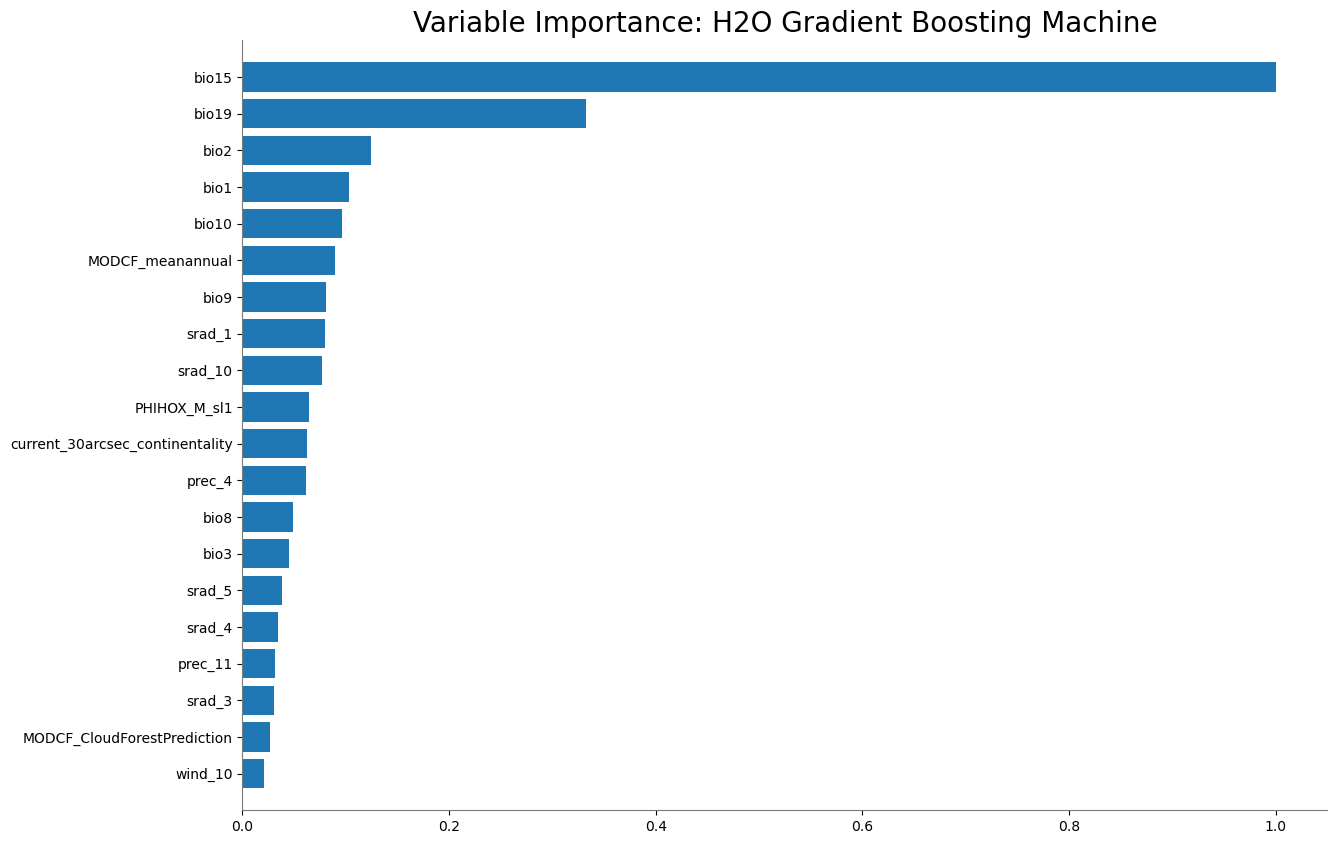

<Figure size 640x480 with 0 Axes>

In [21]:
# Importancia de variables (Feature Importance)
varimp = base_model.varimp(use_pandas=True)
varimp.head(20)

# Gráfico visual
base_model.varimp_plot(num_of_features=20)


In [23]:
perf = best_model.model_performance(test_data=hf)
print("AUC:", perf.auc())
perf.confusion_matrix().show()


AUC: 1.0


,0,1,Error,Rate
0,2365.0,0.0,0.0,(0.0/2365.0)
1,0.0,992.0,0.0,(0.0/992.0)
Total,2365.0,992.0,0.0,(0.0/3357.0)


In [25]:
perf_cv = best_model.model_performance(xval=True)
print("AUC (cross-validation):", perf_cv.auc())

AUC (cross-validation): 0.9890308514628657


## Analisis ##
Una vez realizado el Auto Machine Learning, nos arroja que el modelo que mejor predice las accesiones resistentes a sequía es el modelo **Stacked Ensemble(Ensamble apilado)**. Este modelo combina varios modelos de base por ejemplo:
* GBM (Gradient Boosting Machine): modelos aditivos que optimizan el error gradualmente.
* DRF (Distributed Random Forest): combinaciones de árboles independientes.
* GLM (Generalized Linear Model): base lineal interpretable.
* XRT / XGBoost: árboles de refuerzo más eficientes.
* DeepLearning: redes neuronales densas.
  
lo que le permite poder obtener una predicción mas robusta. Este modelo evalúa todos los modelos con métricas AUC, logloss, RMSE, etc.
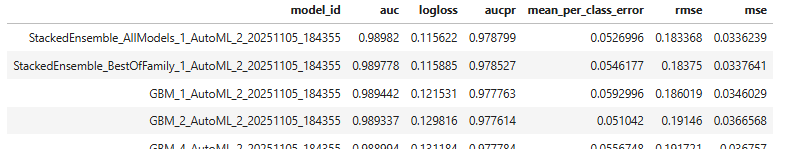

La particularidad de este modelos es la superioridad con respecto a otros  debido a :

| Causa                                       | Explicación                                                                                                                              |                                                                                                                         |
| ------------------------------------------- | ---------------------------------------------------------------------------------------------------------------------------------------- | ------------------------------------------------------------------------------------------------------------------------------------ |
| **Diversidad de modelos**                   | Cada algoritmo captura diferentes patrones: GBM aprende interacciones no lineales, DRF maneja ruido, GLM generaliza relaciones lineales. ||
| **Reducción del sobreajuste**               | La combinación ponderada reduce la varianza individual, creando un modelo más estable.                                                   |                                                        |
| **Optimización del bias-variance tradeoff** | Se equilibran sesgo (modelos simples) y varianza (modelos complejos).                                                                    |                        |



Para uso de FIGS, este modelo es muy bueno ya que logra el mayor **AUC** y el menor **RMSE** 

| Métrica         | Qué me indica                                                                  | Interpretación ecológica para biologos                                                                                                              |
| --------------- | ------------------------------------------------------------------------- | -------------------------------------------------------------------------------------------------------------------------------------- |
| **AUC (0.99)**  | Capacidad de discriminación entre accesiones resistentes y no resistentes | El modelo distingue claramente entre ambientes áridos y húmedos, captando el gradiente de sequía.                                      |
| **RMSE (0.05)** | Error promedio de predicción                                              | Las probabilidades de resistencia son muy precisas, reflejando una coherencia entre los valores ambientales y la respuesta adaptativa. |


Luego, se grafíca las variables que marcacron la mayor importación para el modelo. Hay que recordadr que del dataframe se eliminaron las variables con las cuales se creó la variable objetivo. A continuación se detalla el resultado representado en la gráfica


| Variable                            | Fuente                                                 | Interpretación ecológica FIGS                                                                                                                                                                                  |
| ----------------------------------- | ------------------------------------------------------ | ---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------                                             |
| **bio15**                           | WorldClim – Estacionalidad de la precipitación         | Mide la variabilidad de lluvia anual. Valores altos → alta irregularidad (sequías estacionales fuertes). Variable crítica en ambientes semiáridos y tropicales secos. 
| **bio19**                           | WorldClim – Precipitación del trimestre más frío       | Clave para estrés hídrico invernal. Altos valores → lluvias en meses fríos → ambientes más húmedos; bajos valores → ambientes áridos con déficit en estación seca.|
                                                                       |

Por último realizo validación cruzada, cuyo resultado fue: **AUC (cross-validation): 0.9898204664802563**.  Esto me permite deducir que el modelo no está memorizando los datos, tiene una buena separación de clases, las variables climáticas y edáficas elegidas son muy discriminativas (tienen verdadero poder predictivo).

### Se puede decir que el modelo entiende el gradiente ambiental global de adaptación del Phaseolus *vulgaris# *rente al estrés hídrico. ###

# ************************************************************************************************************************************************************

## Probando el modelo ## 
Con datos imaginarios de datos climaticos referentes a una accesión, voy a probar el modelo con estos datos.
# ************************************************************************************************************************************************************

In [26]:
nueva = h2o.H2OFrame({
    "bio1": [230.5],
    "bio12": [1200.0],
    "bio15": [85.2],
    "bio19": [200.1],
    "AWCh1_M_sl1": [13.7],
    "MODCF_meanannual": [0.45],
    
})

prediccion = best_model.predict(nueva)
print(prediccion)


Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
stackedensemble prediction progress: |███████████████████████████████████████████| (done) 100%
  predict        p0         p1
        0  0.958714  0.0412859
[1 row x 3 columns]



C:\Users\guill\miniconda3\envs\python_env\Lib\site-packages\h2o\job.py:81: UserWarning: Test/Validation dataset is missing column 'SAMPSTAT': substituting in a column of NaN
  warnings.warn(w)
C:\Users\guill\miniconda3\envs\python_env\Lib\site-packages\h2o\job.py:81: UserWarning: Test/Validation dataset is missing column 'ELEVATION': substituting in a column of NaN
  warnings.warn(w)
C:\Users\guill\miniconda3\envs\python_env\Lib\site-packages\h2o\job.py:81: UserWarning: Test/Validation dataset is missing column 'COLLSRC': substituting in a column of NaN
  warnings.warn(w)
C:\Users\guill\miniconda3\envs\python_env\Lib\site-packages\h2o\job.py:81: UserWarning: Test/Validation dataset is missing column 'MODCF_CloudForestPrediction': substituting in a column of NaN
  warnings.warn(w)
C:\Users\guill\miniconda3\envs\python_env\Lib\site-packages\h2o\job.py:81: UserWarning: Test/Validation dataset is missing column 'MODCF_seasonality_concentration': substituting in a column of NaN
  warnings.w

## Uniendo accesiones a probabilidades ##

In [23]:
df = pd.read_csv("./dataset_salida/AML_sequia_h2o.csv")

In [28]:
import pandas as pd
import h2o
from h2o.frame import H2OFrame
from sklearn.model_selection import train_test_split

# Iniciar H2O
h2o.init()

# 1. Cargar dataset usado para AutoML
df = pd.read_csv("./dataset_salida/AML_sequia_h2o.csv")

# 2. Definir variable objetivo y predictores
y = "Resistencia_Sequia"
X = df.columns.drop(y).tolist()

# 3. Separar en X e y
y_values = df[y]
X_values = df.drop(columns=[y])

# 4. Train/test split EXACTO
X_train, X_test, y_train, y_test = train_test_split(
    X_values, y_values, test_size=0.2, stratify=y_values, random_state=42
)

# 5. Convertir X_test a H2OFrame
h2o_test = H2OFrame(X_test)

# 6. Cargar el mejor modelo entrenado de AutoML
aml_model = h2o.load_model("./best_model_h2o/StackedEnsemble_AllModels_1_AutoML_1_20251111_210657")  # AJUSTA EL NOMBRE

# 7. Hacer predicciones
pred = aml_model.predict(h2o_test).as_data_frame()

# 8. Recuperar ACCENUMB del índice original
ACCENUMB_test = df.loc[X_test.index, "ACCENUMB"]

# 9. Crear DataFrame final
df_aml_pred = pd.DataFrame({
    "ACCENUMB": ACCENUMB_test.values,
    "y_true": y_test.values,
    "y_pred": pred["predict"],
    "y_proba": pred["p1"]
})

# 10. Guardar
df_aml_pred.to_csv("dataset_salida/prediccion_AML_sequia.csv", index=False)
print("Archivo generado: prediccion_AML_sequia.csv")


Checking whether there is an H2O instance running at http://localhost:54321. connected.
Please download and install the latest version from: https://h2o-release.s3.amazonaws.com/h2o/latest_stable.html


H2O_cluster_uptime:,1 hour 14 mins
H2O_cluster_timezone:,America/Bogota
H2O_data_parsing_timezone:,UTC
H2O_cluster_version:,3.46.0.7
H2O_cluster_version_age:,7 months and 22 days
H2O_cluster_name:,H2O_from_python_guill_qs4dzc
H2O_cluster_total_nodes:,1
H2O_cluster_free_memory:,15.99 Gb
H2O_cluster_total_cores:,16
H2O_cluster_allowed_cores:,16
H2O_cluster_status:,"locked, healthy"


Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
stackedensemble prediction progress: |███████████████████████████████████████████| (done) 100%


C:\Users\guill\miniconda3\envs\python_env\Lib\site-packages\h2o\frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"


Archivo generado: prediccion_AML_sequia.csv


In [30]:
df_env = pd.read_csv("./dataset_entrada/dataset_reducido_no_colineal.csv")

df_rf_sequia_completo = df_aml_pred.merge(
    df_env, on="ACCENUMB", how="left"
)

df_rf_sequia_completo.to_csv("./dataset_salida/AML_sequia.csv", index=False)
print("Archivo listo: AML_sequia.csv")


Archivo listo: AML_sequia.csv
